# CME Futures: Temporal Feature Engineering

This notebook fits time-series models inside walk-forward CV folds and
extracts temporal features for downstream ML models. Three model families
are applied to the CME futures carry signal:

1. **ARIMA**: Mean-reversion forecasts of carry z-score per product
2. **FFT/Spectral**: Seasonal cycle detection in carry percentage
3. **HMM Regimes**: Portfolio-level carry regime switching

**Learning Objectives**:
- Fit ARIMA on a slowly mean-reverting signal (carry z-score) within
  walk-forward folds to avoid look-ahead bias
- Extract spectral features (dominant period, seasonal energy) from
  rolling FFT applied to carry dynamics
- Use filtered (not smoothed) HMM probabilities for regime features
- Combine temporal features with Ch8 cross-sectional features

**Book Reference**: Chapter 9, Sections 9.3-9.5

**Prerequisites**: [`02_labels`](02_labels.ipynb). It writes the label parquet this
notebook reads, and its date index is what the folds below are derived from.
`03_financial_features` runs as a parallel branch on the same raw prices; the two
feature sets meet downstream in Chapter 11.

In [1]:
"""CME Futures: Temporal Feature Engineering."""

import multiprocessing
import re
import time
import warnings
from datetime import date

# Pin the start method to fork before any pool-using import: Python 3.14 defaults to
# forkserver, which re-executes this script in every StatsForecast worker.
if multiprocessing.get_start_method(allow_none=True) is None:
    multiprocessing.set_start_method("fork")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from hmmlearn.hmm import GaussianHMM
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

from data import load_cme_futures
from utils.artifact_specs import load_setup_config, resolve_label_buffer
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "cme_futures"
MAX_PRODUCTS = 0  # 0 = all products; >0 limits ARIMA/HMM/FFT to N products
FFT_WINDOW = 252  # FFT window (trading days)
FFT_TARGET_PERIODS = [63, 126]  # quarterly and semi-annual, in trading days

The universe and the two carry windows come from `config/setup.yaml`, which is what
`03_financial_features` reads to build `carry_zscore_63d`. Reading them here is what
makes the carry series in section 2 the same series that stage carries under that
name.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
FEATURES_DIR = CASE_DIR / "features"
LABELS_DIR = CASE_DIR / "labels"
STRATEGY_ID = CASE_STUDY_ID

SETUP = load_setup_config(CASE_STUDY_ID)
PRODUCT_GROUPS = SETUP["universe"]["product_groups"]
ALL_PRODUCTS = [p for products in PRODUCT_GROUPS.values() for p in products]
assert len(ALL_PRODUCTS) == SETUP["universe"]["n_products"], (
    f"setup.yaml declares {SETUP['universe']['n_products']} products, "
    f"product_groups lists {len(ALL_PRODUCTS)}"
)

CARRY_SMOOTHING = int(SETUP["features"]["windows"]["carry_smoothing"])
CARRY_ZSCORE_WINDOW = int(SETUP["features"]["windows"]["carry_zscore"][0])

if MAX_PRODUCTS > 0:
    ARIMA_PRODUCTS = ALL_PRODUCTS[:MAX_PRODUCTS]
else:
    ARIMA_PRODUCTS = ALL_PRODUCTS

## 1. Load Data and Resolve the Fold Contract

Load prices from Ch7 output, then resolve the walk-forward boundaries **before
any model is fitted**. Every fit below is sealed against these boundaries, so
they have to exist first.

The folds are derived from the label frame, not the price frame. The consumer
side (`load_modeling_dataset`) derives them from the label frame too, and the
two indexes are not the same: the label parquet starts later than the prices
because the forward return needs a window to resolve. Deriving both sides from
the same frame is what makes the `fold` ids in this artifact mean the same
thing downstream as they do here.

In [4]:
# Load raw data and compute carry
df = load_cme_futures().rename({"session_date": "timestamp", "tenor": "position"})

if MAX_PRODUCTS > 0:
    df = df.filter(pl.col("product").is_in(ARIMA_PRODUCTS))

print(f"Loaded {len(df):,} rows, {df['product'].n_unique()} products")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Loaded 312,859 rows, 30 products
Date range: 2011-01-03 to 2025-12-31


Two boundaries are resolved here and used everywhere below.

The **label** is the case study's configured primary rather than a name typed here.
The same key picks the label file `02_labels` wrote, the buffer that spaces the
folds, and the HAC lag in section 8.

The **holdout seal for the supervised screen** binds on the outcome endpoint, not on
the decision date: a decision is realized `LABEL_HORIZON_SESSIONS` sessions later, so
the last decision date section 8 may score is that many sessions before the rule.
Those sessions are counted on the traded calendar in the data.

In [5]:
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
assert LABEL_BUFFER, f"No label buffer configured for {PRIMARY_LABEL}"
LABEL_HORIZON_SESSIONS = int(re.match(r"^(\d+)", LABEL_BUFFER).group(1))

label_frame = pl.read_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")
splits = generate_cv_splits(
    label_frame.select("timestamp").unique().sort("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
)


def _as_date(value) -> date:
    return pd.Timestamp(value).date()


HOLDOUT_START = _as_date(load_evaluation_config(CASE_STUDY_ID)["holdout_start"])
_sessions = df.select("timestamp").unique().sort("timestamp")["timestamp"].to_list()
_pre_holdout = [d for d in _sessions if d < HOLDOUT_START]
LAST_SEALED_DECISION_DATE = _pre_holdout[-(LABEL_HORIZON_SESSIONS + 1)]

print(f"CV splits: {len(splits)} folds  (label buffer {LABEL_BUFFER})")
for s in splits:
    print(
        f"  Fold {s['fold']}: train {s['train_start']} → {s['train_end']}, "
        f"val {s['val_start']} → {s['val_end']}"
    )
print(f"Holdout opens {HOLDOUT_START}; last sealed decision date {LAST_SEALED_DECISION_DATE}")

CV splits: 5 folds  (label buffer 5D)
  Fold 0: train 2015-01-05 00:00:00 → 2022-12-22 00:00:00, val 2023-01-03 00:00:00 → 2023-12-21 00:00:00
  Fold 1: train 2014-01-03 00:00:00 → 2021-12-23 00:00:00, val 2022-01-03 00:00:00 → 2022-12-30 00:00:00
  Fold 2: train 2013-01-01 00:00:00 → 2020-12-24 00:00:00, val 2021-01-05 00:00:00 → 2021-12-31 00:00:00
  Fold 3: train 2012-01-04 00:00:00 → 2019-12-26 00:00:00, val 2020-01-06 00:00:00 → 2021-01-04 00:00:00
  Fold 4: train 2011-01-05 00:00:00 → 2018-12-26 00:00:00, val 2019-01-04 00:00:00 → 2020-01-03 00:00:00
Holdout opens 2024-01-01; last sealed decision date 2023-12-21


### The Fold Contract

The figure draws what the saved artifact will contain: per fold, the window each
model's parameters are estimated on, the window they are then applied to out of
sample, and the sealed holdout. It is the one picture in which a parameter-level
leak would be visible - a fitted span reaching to the right of its own validation
span, or any span crossing the rule.

Every bar stops short of the rule, because `cme_futures` writes features for the CV
folds only. A downstream stage that needs a holdout *fold* gets one from
`append_holdout_fold_if_needed`.

The bars are fold windows, and they are not the artifact's row index. That is keyed
on `(fold, timestamp, product, position)` over the full price calendar, so rows
dated inside the seal do exist; what makes them sealed is which columns carry a
value. Section 7 prints that count per column. An unsupervised transform is sealed
on its *estimation* window, so a value emitted **for** a sealed date from a pre-seal
fit is what downstream needs.

Section 8 stops earlier than the rule again, on the outcome endpoint rather than the
decision date; that boundary is printed above and is too close to the rule to draw
apart from it here.

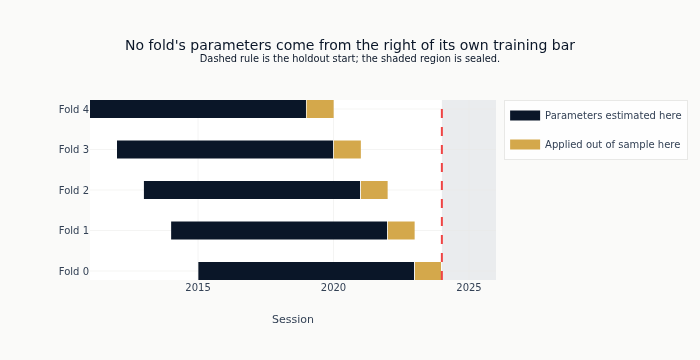

In [6]:
fig = go.Figure()
_span_style = {
    "Parameters estimated here": COLORS["blue"],
    "Applied out of sample here": COLORS["amber"],
}
_seen: set[str] = set()
for split in splits:
    row = f"Fold {split['fold']}"
    for kind, (start, end) in (
        ("Parameters estimated here", (split["train_start"], split["train_end"])),
        ("Applied out of sample here", (split["val_start"], split["val_end"])),
    ):
        fig.add_trace(
            go.Scatter(
                x=[pd.Timestamp(start).isoformat(), pd.Timestamp(end).isoformat()],
                y=[row, row],
                mode="lines",
                line={"width": 18, "color": _span_style[kind]},
                name=kind,
                legendgroup=kind,
                showlegend=kind not in _seen,
            )
        )
        _seen.add(kind)

fig.add_vrect(
    x0=pd.Timestamp(HOLDOUT_START).isoformat(),
    x1=pd.Timestamp(df["timestamp"].max()).isoformat(),
    fillcolor=COLORS["neutral"],
    opacity=0.10,
    line_width=0,
    layer="below",
)
fig.add_vline(
    x=pd.Timestamp(HOLDOUT_START).isoformat(), line_dash="dash", line_color=COLORS["negative"]
)
fig.update_layout(
    title=(
        "No fold's parameters come from the right of its own training bar"
        "<br><sup>Dashed rule is the holdout start; the shaded region is sealed.</sup>"
    ),
    xaxis_title="Session",
    yaxis_title="",
    height=360,
    margin={"l": 90},
)
fig.show()

## 2. Compute Carry for Temporal Modeling

The temporal models need carry as one series per product and date. Stage 03 writes it
position-expanded, so this notebook recomputes it from the raw prices instead: the
formula is the annualized front-deferred spread, and both smoothing windows are the
ones read from `setup.yaml` above, so the series is `carry_zscore_63d` under a
different shape rather than a second definition of carry.

In [7]:
def compute_carry(data: pl.DataFrame) -> pl.DataFrame:
    """Compute carry percentage from front and deferred month prices."""
    # Raw (unadjusted) close: the term-structure spread must read contemporaneous
    # tenor levels, not the ratio-adjusted series whose levels encode roll history.
    front = (
        data.filter(pl.col("position") == 0)
        .select(["product", "timestamp", "raw_close"])
        .rename({"raw_close": "c0_price"})
    )
    second = (
        data.filter(pl.col("position") == 1)
        .select(["product", "timestamp", "raw_close"])
        .rename({"raw_close": "c1_price"})
    )

    carry_df = front.join(second, on=["product", "timestamp"], how="inner")
    carry_df = carry_df.with_columns(
        ((pl.col("c0_price") - pl.col("c1_price")) / pl.col("c0_price") * 12).alias("carry_pct")
    )

    # Smoothed carry and z-score, on the windows setup.yaml declares
    carry_df = carry_df.sort(["product", "timestamp"])
    carry_df = carry_df.with_columns(
        pl.col("carry_pct")
        .rolling_mean(window_size=CARRY_SMOOTHING)
        .over("product")
        .alias("carry_smoothed"),
    )
    carry_df = carry_df.with_columns(
        (
            (
                pl.col("carry_smoothed")
                - pl.col("carry_smoothed").rolling_mean(CARRY_ZSCORE_WINDOW).over("product")
            )
            / pl.col("carry_smoothed")
            .rolling_std(CARRY_ZSCORE_WINDOW)
            .over("product")
            .clip(lower_bound=1e-6)
        )
        .clip(lower_bound=-5.0, upper_bound=5.0)
        .alias("carry_zscore")
    )

    return carry_df.select(
        ["product", "timestamp", "carry_pct", "carry_smoothed", "carry_zscore"]
    ).drop_nulls()


carry = compute_carry(df)
print(f"Carry data: {len(carry):,} product-dates")

Carry data: 108,980 product-dates


---

## 3. ARIMA on Carry Z-Score

The carry signal is slowly mean-reverting (term structure changes gradually), and
ARIMA captures the predictable component of the carry z-score. The order is not
fixed here: `AutoARIMA` runs the stepwise Hyndman-Khandakar search, taking `p` and
`q` up to 5, choosing the differencing order `d` by a unit-root test, and ranking
candidates by AICc. The `max_order` cap on `p + q` is not in force, because
`statsforecast` applies it in `search_arima`, the branch the non-stepwise search
takes (`statsforecast/arima.py:868`). `season_length=1` leaves the
seasonal terms out of that search; the seasonality this case study cares about is
read by the FFT in section 4 instead.

**Walk-forward discipline**: For each CV fold we run a single
`StatsForecast.cross_validation` (`h=1`, `step_size=1`, `refit=21`) over the
fold window. Every ARIMA value it emits, for the later training dates and the
test window alike, is an **out-of-sample 1-step-ahead forecast**: the value at
date t is predicted from data strictly earlier than t, with the (p,d,q) order
re-selected by AICc every 21 steps. There are no in-sample fitted values; the
walk simply begins after the `burnin=252` warm-up. This produces causal
features across each fold, which downstream per-fold CV requires.

### Run ARIMA Per Fold (Multi-Series Walk-Forward)

For each CV fold we bundle every product into a single long-format frame
(`unique_id=product`, `ds=date`, `y=carry_zscore`) and call
`StatsForecast.cross_validation` once. The library produces 1-step-ahead OOS
forecasts for every (product, date) inside the test window of the CV, with
`refit=21` re-selecting (p,d,q) per series via AICc every 21 steps and
`n_jobs=-1` distributing series across CPU cores. This is the same
walk-forward primitive used by `09_model_based_features/10_uncertainty_features`
- single canonical pattern across the book. The first `burnin=252` rows of
each product's in-fold history form the warm-up for the initial fit and
receive NaN features.

In [8]:
ARIMA_BURNIN = 252
ARIMA_REFIT_FREQ = 21

arima_results = []
arima_t0 = time.time()

_carry_ts_dtype = carry.schema["timestamp"]


def _date_lit(value) -> pl.Expr:
    """Cast a Python date/timestamp to the carry frame's timestamp dtype.

    The carry frame carries `pl.Date`, so the bound and the column compare on
    the same type and the inclusive upper bound below means what it says. The
    cast is what enforces that: a frame promoted to `pl.Datetime` would compare
    a midnight bound against intraday stamps and silently drop the last session.
    """

    return pl.lit(pd.Timestamp(value).date()).cast(_carry_ts_dtype)


for fold_idx, split in enumerate(splits):
    train_start = pd.Timestamp(split["train_start"]).date()
    train_end = pd.Timestamp(split["train_end"]).date()
    test_start = pd.Timestamp(split["val_start"]).date()
    test_end = pd.Timestamp(split["val_end"]).date()

    print(
        f"\nFold {fold_idx}: train {train_start}→{train_end}, test {test_start}→{test_end}",
        flush=True,
    )

    # Build long-format input for all products in this fold
    in_window = (
        carry.filter(pl.col("product").is_in(ARIMA_PRODUCTS))
        .filter(
            (pl.col("timestamp") >= _date_lit(split["train_start"]))
            & (pl.col("timestamp") <= _date_lit(split["val_end"]))
        )
        .drop_nulls(subset=["carry_zscore"])
        .sort(["product", "timestamp"])
    )
    series_lengths = in_window.group_by("product").len().sort("len")
    eligible = series_lengths.filter(pl.col("len") >= ARIMA_BURNIN + 30)["product"].to_list()
    if not eligible:
        print("  no eligible products for fold")
        continue
    in_window = in_window.filter(pl.col("product").is_in(eligible))

    # n_windows must be uniform across series, so the shortest eligible series sets it:
    # every product walks over its last (shortest length - burnin) rows, and one with
    # more in-fold history than that loses the excess too. Measured under the seal cell.
    min_len = int(series_lengths.filter(pl.col("product").is_in(eligible))["len"].min())
    n_windows = min_len - ARIMA_BURNIN

    fold_input = pd.DataFrame(
        {
            "unique_id": in_window["product"].to_list(),
            "ds": pd.to_datetime(in_window["timestamp"].to_list()),
            "y": in_window["carry_zscore"].to_numpy(),
        }
    )

    sf = StatsForecast(
        models=[AutoARIMA(season_length=1)],
        freq="B",
        n_jobs=-1,
    )
    cv = sf.cross_validation(
        df=fold_input,
        h=1,
        step_size=1,
        n_windows=n_windows,
        refit=ARIMA_REFIT_FREQ,
    )

    # Map results back per product, padding with NaN for the burn-in head
    cv_pl = pl.from_pandas(cv).rename({"unique_id": "product", "ds": "timestamp"})
    cv_pl = cv_pl.with_columns(pl.col("timestamp").cast(pl.Date))
    fold_df = (
        in_window.select(["product", "timestamp"])
        .join(
            cv_pl.select(["product", "timestamp", "AutoARIMA", "y"]),
            on=["product", "timestamp"],
            how="left",
        )
        .with_columns(
            arima_carry_forecast=pl.col("AutoARIMA"),
            arima_carry_residual=pl.col("y") - pl.col("AutoARIMA"),
            fold=pl.lit(fold_idx, dtype=pl.Int64),
        )
        .select(["timestamp", "product", "arima_carry_forecast", "arima_carry_residual", "fold"])
    )
    arima_results.append(fold_df)
    print(f"  {len(eligible)} products fitted, n_windows={n_windows}", flush=True)

arima_elapsed = time.time() - arima_t0


Fold 0: train 2015-01-05→2022-12-22, test 2023-01-03→2023-12-21


  30 products fitted, n_windows=1276



Fold 1: train 2014-01-03→2021-12-23, test 2022-01-03→2022-12-30


  30 products fitted, n_windows=1023



Fold 2: train 2013-01-01→2020-12-24, test 2021-01-05→2021-12-31


  30 products fitted, n_windows=766



Fold 3: train 2012-01-04→2019-12-26, test 2020-01-06→2021-01-04


  30 products fitted, n_windows=508



Fold 4: train 2011-01-05→2018-12-26, test 2019-01-04→2020-01-03


  30 products fitted, n_windows=251


In [9]:
if arima_results:
    arima_pl = pl.concat(arima_results)
    if arima_pl["timestamp"].dtype != pl.Date:
        arima_pl = arima_pl.with_columns(pl.col("timestamp").cast(pl.Date))
    print(
        f"\nARIMA total: {len(arima_pl):,} rows across "
        f"{arima_pl['product'].n_unique()} products, "
        f"{arima_pl['fold'].n_unique()} folds in {arima_elapsed:.0f}s"
    )
else:
    arima_pl = pl.DataFrame(
        schema={
            "timestamp": pl.Date,
            "product": pl.String,
            "arima_carry_forecast": pl.Float64,
            "arima_carry_residual": pl.Float64,
            "fold": pl.Int64,
        }
    )
    print("No ARIMA results generated")


ARIMA total: 329,925 rows across 30 products, 5 folds in 1388s


**The ARIMA seal, executed.** The paragraph above claims the walk never reaches
outside its own fold. A claim in prose is not a check, so the next cell asserts it
against the emitted frame: every row a fold contributes is dated inside that fold's
own `train_start`-`val_end` span, and no fold reaches the holdout.

It then measures what the uniform walk length costs. `n_windows` is set by the
shortest eligible series, so a product with more in-fold history than that one loses
the excess, and the fold-level counts printed above shrink as the folds get earlier.
The count below says where the loss lands: against the product-sessions each fold's
validation window actually quotes. That is a coverage question rather than a seal
question, and it is what separates the ARIMA row in the section 6 coverage table -
which is over the whole panel, most of it outside any walk - from the coverage the
downstream join sees.

In [10]:
if len(arima_pl) > 0:
    for split in splits:
        rows = arima_pl.filter(pl.col("fold") == split["fold"])
        if len(rows) == 0:
            continue
        assert rows["timestamp"].min() >= _as_date(split["train_start"]), (
            f"fold {split['fold']}: ARIMA row before its own train_start"
        )
        assert rows["timestamp"].max() <= _as_date(split["val_end"]), (
            f"fold {split['fold']}: ARIMA row after its own val_end"
        )
    assert arima_pl["timestamp"].max() < HOLDOUT_START, "ARIMA emitted a holdout-dated row"
    print(
        f"ARIMA seal holds across {arima_pl['fold'].n_unique()} folds; "
        f"last emitted date {arima_pl['timestamp'].max()} < holdout start {HOLDOUT_START}"
    )
    print("Validation product-sessions carrying an ARIMA value, per fold:")
    for split in splits:
        _in_val = (pl.col("timestamp") >= _as_date(split["val_start"])) & (
            pl.col("timestamp") <= _as_date(split["val_end"])
        )
        quoted = carry.filter(_in_val).height
        covered = (
            arima_pl.filter((pl.col("fold") == split["fold"]) & _in_val)
            .drop_nulls("arima_carry_forecast")
            .height
        )
        print(
            f"  fold {split['fold']}: {covered:>6,} of {quoted:>6,} quoted "
            f"({100 * covered / max(quoted, 1):.1f}%)"
        )

ARIMA seal holds across 5 folds; last emitted date 2023-12-21 < holdout start 2024-01-01
Validation product-sessions carrying an ARIMA value, per fold:
  fold 0:  7,430 of  7,430 quoted (100.0%)
  fold 1:  7,561 of  7,561 quoted (100.0%)
  fold 2:  7,488 of  7,488 quoted (100.0%)
  fold 3:  7,465 of  7,465 quoted (100.0%)
  fold 4:  7,421 of  7,516 quoted (98.7%)


---

## 4. FFT Spectral Features on Carry

Agriculture and energy futures have well-documented seasonal cycles.
We apply rolling FFT to carry percentage to extract:
- Dominant period (cycle length in days)
- Spectral energy at quarterly (~63d) and semi-annual (~126d) frequencies
- Spectral entropy (how concentrated the spectrum is)

Helper: compute FFT-derived statistics for a single rolling segment.

In [11]:
def _fft_window_features(segment: np.ndarray, target_periods: list[int]) -> dict[str, float]:
    centered = segment - segment.mean()
    fft_vals = np.fft.rfft(centered)
    power = np.abs(fft_vals) ** 2
    freqs = np.fft.rfftfreq(len(segment))
    total_power = np.sum(power[1:])

    output = {
        "total_power": float(total_power),
        "dominant_period": float("nan"),
        "spectral_entropy": float("nan"),
    }
    for period in target_periods:
        output[f"energy_{period}d"] = float("nan")

    if len(power) <= 1 or total_power <= 0:
        return output

    dom_idx = np.argmax(power[1:]) + 1
    if freqs[dom_idx] > 0:
        output["dominant_period"] = float(1.0 / freqs[dom_idx])

    p_norm = power[1:] / total_power
    p_norm = p_norm[p_norm > 0]
    output["spectral_entropy"] = float(-np.sum(p_norm * np.log(p_norm)))

    for period in target_periods:
        target_freq = 1.0 / period
        freq_idx = np.argmin(np.abs(freqs - target_freq))
        low_idx = max(1, freq_idx - 1)
        high_idx = min(len(power), freq_idx + 2)
        output[f"energy_{period}d"] = float(np.sum(power[low_idx:high_idx]) / total_power)
    return output

Compute rolling FFT features aligned with the original signal index.

In [12]:
def rolling_fft_features(
    signal: np.ndarray,
    window: int = 252,
    target_periods: list[int] | None = None,
) -> dict[str, np.ndarray]:
    if target_periods is None:
        target_periods = [63, 126]

    n = len(signal)
    spectral_energy = np.full(n, np.nan)
    dominant_period = np.full(n, np.nan)
    spectral_entropy = np.full(n, np.nan)
    freq_energies = {p: np.full(n, np.nan) for p in target_periods}

    for t in range(window, n):
        window_stats = _fft_window_features(signal[t - window : t], target_periods)
        spectral_energy[t] = window_stats["total_power"]
        dominant_period[t] = window_stats["dominant_period"]
        spectral_entropy[t] = window_stats["spectral_entropy"]
        for period in target_periods:
            freq_energies[period][t] = window_stats[f"energy_{period}d"]

    result = {
        "fft_spectral_energy": spectral_energy,
        "fft_dominant_period": dominant_period,
        "fft_spectral_entropy": spectral_entropy,
    }
    for period, energy in freq_energies.items():
        result[f"fft_energy_{period}d"] = energy
    return result

### Run FFT per product

Unlike ARIMA (which estimates coefficients) and HMM (which fits transition
matrices), FFT is a **deterministic transformation** with no fitted
parameters, so there is nothing to overfit. The rolling window uses only
past data at each point, so walk-forward fitting is unnecessary.
This is the same discipline as any rolling feature (e.g., rolling mean).

In [13]:
fft_results = []

for product in ARIMA_PRODUCTS:
    prod_carry = (
        carry.filter(pl.col("product") == product)
        .sort("timestamp")
        .drop_nulls(subset=["carry_pct"])
    )
    if len(prod_carry) < FFT_WINDOW + 50:
        continue

    signal = prod_carry["carry_pct"].to_numpy()
    dates = prod_carry["timestamp"].to_list()

    fft_out = rolling_fft_features(signal, window=FFT_WINDOW, target_periods=FFT_TARGET_PERIODS)

    prod_df = pl.DataFrame({"timestamp": dates, "product": product, **fft_out})
    fft_results.append(prod_df)
    valid_count = prod_df.drop_nulls(subset=["fft_spectral_energy"]).height
    print(f"  {product}: {valid_count} valid FFT observations")

  ES: 3782 valid FFT observations
  NQ: 3752 valid FFT observations
  YM: 3743 valid FFT observations


  RTY: 2049 valid FFT observations
  ZN: 3638 valid FFT observations
  ZB: 3659 valid FFT observations


  ZF: 3331 valid FFT observations
  ZT: 3239 valid FFT observations
  CL: 3786 valid FFT observations


  NG: 3787 valid FFT observations
  HO: 3784 valid FFT observations
  RB: 3782 valid FFT observations


  GC: 3782 valid FFT observations
  SI: 3775 valid FFT observations
  HG: 3784 valid FFT observations


  PL: 3772 valid FFT observations
  6E: 3772 valid FFT observations
  6J: 3735 valid FFT observations


  6B: 3707 valid FFT observations
  6A: 3753 valid FFT observations
  6C: 3727 valid FFT observations


  6S: 3340 valid FFT observations
  ZC: 3691 valid FFT observations
  ZS: 3691 valid FFT observations


  ZW: 3691 valid FFT observations
  ZM: 3691 valid FFT observations
  ZL: 3691 valid FFT observations


  LE: 3682 valid FFT observations
  HE: 3682 valid FFT observations
  GF: 3682 valid FFT observations


The FFT values are replicated once per fold. FFT estimates nothing, so every fold
gets the same numbers; the `fold` column is what the downstream join keys on, and it
has to be present for every feature family or that join needs a special case for
this one. The row counts either side of the replication are printed below.

In [14]:
if fft_results:
    fft_base = pl.concat(fft_results)
    fft_pl = pl.concat([fft_base.with_columns(pl.lit(s["fold"]).alias("fold")) for s in splits])
    print(f"\nFFT signal: {len(fft_base):,} unique (product, timestamp) rows")
    print(
        f"FFT total: {len(fft_pl):,} rows, {fft_pl['product'].n_unique()} products, "
        f"{fft_pl['fold'].n_unique()} folds"
    )
else:
    fft_pl = pl.DataFrame(
        schema={
            "timestamp": pl.Date,
            "product": pl.String,
            "fft_spectral_energy": pl.Float64,
            "fft_dominant_period": pl.Float64,
            "fft_spectral_entropy": pl.Float64,
            "fft_energy_63d": pl.Float64,
            "fft_energy_126d": pl.Float64,
            "fold": pl.Int64,
        }
    )
    print("No FFT results generated")


FFT signal: 108,980 unique (product, timestamp) rows
FFT total: 544,900 rows, 30 products, 5 folds


**The FFT seal, executed.** FFT estimates no parameters, so the only way it could
look ahead is through the window itself. That is checked by recomputation rather
than by reading the slice bounds: delete every observation after date `t` and the
value at `t` has to come back unchanged.

In [15]:
if fft_results:
    probe_product = fft_base["product"][0]
    probe_signal = (
        carry.filter(pl.col("product") == probe_product)
        .sort("timestamp")
        .drop_nulls(subset=["carry_pct"])["carry_pct"]
        .to_numpy()
    )
    probe_t = FFT_WINDOW + 100
    full_pass = rolling_fft_features(
        probe_signal, window=FFT_WINDOW, target_periods=FFT_TARGET_PERIODS
    )
    truncated = rolling_fft_features(
        probe_signal[: probe_t + 1], window=FFT_WINDOW, target_periods=FFT_TARGET_PERIODS
    )
    for key in full_pass:
        assert np.isclose(full_pass[key][probe_t], truncated[key][probe_t], equal_nan=True), key
    print(
        f"FFT seal holds: {probe_product} at index {probe_t} is identical when the "
        f"{len(probe_signal) - probe_t - 1} later observations are deleted"
    )

FFT seal holds: ES at index 352 is identical when the 3429 later observations are deleted


---

## 5. HMM Regime Detection on Portfolio Carry

A 2-state Gaussian HMM is fitted to the portfolio-level carry signal
(equal-weighted carry across all products). The states capture
"carry-favorable" vs "carry-unfavorable" macro regimes.

**Walk-forward**: For each fold, fit on training window, apply filtered
probabilities to train+test. Label switching is prevented by sorting the states
on their fitted mean carry, which is the quantity the emitted feature name
claims - see `sort_states_by_carry` below.

In [16]:
def fit_hmm_kmeans_init(X: np.ndarray, n_states: int = 2, random_state: int = 42) -> GaussianHMM:
    """Fit HMM with k-means-seeded initialization.

    K-means provides better starting points than random initialization,
    reducing sensitivity to EM local optima.
    """
    kmeans = KMeans(n_clusters=n_states, random_state=random_state, n_init=10)
    kmeans.fit(X)

    model = GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=200,
        random_state=random_state,
        init_params="st",  # Only init startprob and transmat
    )

    # Set emission parameters from k-means
    model.means_ = kmeans.cluster_centers_
    model.covars_ = np.array(
        [np.cov(X[kmeans.labels_ == k].T).reshape(1, 1) + np.eye(1) * 1e-6 for k in range(n_states)]
    )

    model.fit(X)
    return model

Helper: enforce stable state labeling by sorting states on mean carry.

In [17]:
def sort_states_by_carry(model: GaussianHMM) -> np.ndarray:
    """Sort HMM states by mean carry (ascending), so state 1 is the high-carry state.

    EM returns the two states in an arbitrary order, so without a rule the same
    fitted state can be state 0 in one fold and state 1 in the next and the feature
    means different things across folds. The rule has to be the quantity the feature
    name claims: `hmm_carry_regime_prob` is emitted as P(high-carry), so the states
    are ordered on their fitted mean carry. The per-fold means are printed by the
    fit-stability section below, which is where that ordering can be checked.
    """
    means = np.array([float(model.means_[k][0]) for k in range(model.n_components)])
    return np.argsort(means)  # low-carry first

Helper: compute filtered probabilities via forward recursion (no look-ahead).

In [18]:
def compute_filtered_probs(model: GaussianHMM, X: np.ndarray) -> np.ndarray:
    """Compute filtered probabilities P(state_t | obs_{1:t}).

    Uses the forward algorithm to avoid look-ahead bias inherent in
    smoothed (Viterbi/posterior) probabilities.

    Note: Uses ``model._compute_log_likelihood()`` (private API, hmmlearn >=0.3).
    If this breaks in a future version, replace with ``model.score_samples(X)``.
    """
    framelogprob = model._compute_log_likelihood(X)
    n_samples = X.shape[0]
    n_components = model.n_components

    log_startprob = np.log(model.startprob_ + 1e-300)
    log_transmat = np.log(model.transmat_ + 1e-300)

    fwdlattice = np.zeros((n_samples, n_components))
    fwdlattice[0] = log_startprob + framelogprob[0]

    for t in range(1, n_samples):
        for j in range(n_components):
            fwdlattice[t, j] = framelogprob[t, j] + np.logaddexp.reduce(
                fwdlattice[t - 1] + log_transmat[:, j]
            )

    # Normalize to get probabilities
    log_normalizer = np.logaddexp.reduce(fwdlattice, axis=1, keepdims=True)
    log_probs = fwdlattice - log_normalizer
    return np.exp(log_probs)

### Compute Portfolio-Level Carry and Fit HMM per Fold

The observation the HMM sees is one number per session: carry averaged across the
product universe. Which products go into that average has to be the same from one
session to the next, or the number moves when the basket changes rather than when
carry does. CME sectors keep different holiday calendars, so a session that closes
part of the universe leaves the rest settling, and averaging over whatever settled
swings the observation for a reason that has nothing to do with carry.

So a product that does not settle keeps the carry of its last settlement for
`HOLD_LAST_SETTLE_SESSIONS` sessions, carried forward only and never backward. A
product absent for longer, or not yet trading, stays out of that session's average.

The hold is a partial repair and the cell below measures it rather than claiming it:
how many absences there are, how many are the single closed session the holiday
argument describes, how long the longest one runs, and what share of the missing
product-sessions a two-session hold actually fills. What the hold does not reach
shows up as a smaller basket, and the per-session basket count is printed under it.

In [19]:
HOLD_LAST_SETTLE_SESSIONS = 2

_carry_sessions = carry.select("timestamp").unique().sort("timestamp")["timestamp"].to_list()
_session_index = {d: i for i, d in enumerate(_carry_sessions)}
_absence_runs = []
for (_product,), _product_rows in carry.group_by("product"):
    _seen = np.sort(np.array([_session_index[d] for d in _product_rows["timestamp"].to_list()]))
    _gaps = np.diff(_seen) - 1
    _absence_runs.extend(int(g) for g in _gaps[_gaps > 0])
_absence_runs = np.array(_absence_runs)
_missing_cells = int(_absence_runs.sum())
_held_cells = int(np.minimum(_absence_runs, HOLD_LAST_SETTLE_SESSIONS).sum())

print(
    f"Interior absences: {len(_absence_runs):,} runs over {_missing_cells:,} product-sessions "
    f"of {len(_carry_sessions) * carry['product'].n_unique():,}"
)
print(
    f"  one session: {(_absence_runs == 1).sum():,}   two: {(_absence_runs == 2).sum():,}   "
    f"longer: {(_absence_runs > 2).sum():,}   longest run: {_absence_runs.max()} sessions"
)
print(
    f"Holding {HOLD_LAST_SETTLE_SESSIONS} sessions fills {_held_cells:,} of "
    f"{_missing_cells:,} missing product-sessions ({100 * _held_cells / _missing_cells:.0f}%)"
)

_basket_grid = (
    carry.select("timestamp").unique().join(carry.select("product").unique(), how="cross")
)
held_carry = (
    _basket_grid.join(carry, on=["product", "timestamp"], how="left")
    .sort(["product", "timestamp"])
    .with_columns(pl.col("carry_pct").forward_fill(limit=HOLD_LAST_SETTLE_SESSIONS).over("product"))
)

portfolio_carry = (
    held_carry.group_by("timestamp")
    .agg(
        pl.col("carry_pct").mean().alias("portfolio_carry"),
        pl.col("carry_pct").is_not_null().sum().alias("products_in_basket"),
    )
    .sort("timestamp")
    .drop_nulls()
)

print(f"Portfolio carry: {len(portfolio_carry):,} sessions")
print(
    f"Products behind each session's average: "
    f"{portfolio_carry['products_in_basket'].min()} to "
    f"{portfolio_carry['products_in_basket'].max()}, "
    f"median {portfolio_carry['products_in_basket'].median():.0f} of {len(ALL_PRODUCTS)}"
)

Interior absences: 1,979 runs over 2,978 product-sessions of 113,760
  one session: 1,583   two: 205   longer: 191   longest run: 20 sessions
Holding 2 sessions fills 2,375 of 2,978 missing product-sessions (80%)
Portfolio carry: 3,792 sessions
Products behind each session's average: 6 to 30, median 29 of 30


Helper: compute contiguous regime duration from most-likely state sequence.

In [20]:
def _regime_duration(test_states: np.ndarray) -> np.ndarray:
    duration = np.zeros(len(test_states))
    duration[0] = 1
    for t in range(1, len(test_states)):
        if test_states[t] == test_states[t - 1]:
            duration[t] = duration[t - 1] + 1
        else:
            duration[t] = 1
    return duration

Helper: fit one fold and return HMM features for train+test period.

In [21]:
def _fit_hmm_fold(portfolio_df: pl.DataFrame, split: dict[str, str], fold_idx: int):
    """Fit HMM on training data, forward-filter on train+test, return probs and parameters.

    Returns ``(fold_df, params)`` where ``params`` carries the fitted quantities in the
    sorted state order, so the fit-stability section can draw what was estimated rather
    than what the emitted features happened to average to.
    """
    train_start = pd.Timestamp(split["train_start"]).date()
    train_end = pd.Timestamp(split["train_end"]).date()
    test_start = pd.Timestamp(split["val_start"]).date()
    test_end = pd.Timestamp(split["val_end"]).date()

    train_carry = portfolio_df.filter(
        (pl.col("timestamp") >= train_start) & (pl.col("timestamp") <= train_end)
    )
    test_carry = portfolio_df.filter(
        (pl.col("timestamp") >= test_start) & (pl.col("timestamp") <= test_end)
    )
    if len(train_carry) < 200 or len(test_carry) < 20:
        print(f"Fold {fold_idx}: Skipping (insufficient data)")
        return None, None

    X_train = train_carry["portfolio_carry"].to_numpy().reshape(-1, 1)
    X_test = test_carry["portfolio_carry"].to_numpy().reshape(-1, 1)
    try:
        model = fit_hmm_kmeans_init(X_train, n_states=2, random_state=42 + fold_idx)
    except Exception as exc:
        print(f"Fold {fold_idx}: HMM fit failed ({exc})")
        return None, None

    order = sort_states_by_carry(model)

    # Forward-filter on train+test (causal - no look-ahead)
    X_full = np.vstack([X_train, X_test])
    full_probs = compute_filtered_probs(model, X_full)[:, order]
    all_dates = train_carry["timestamp"].to_list() + test_carry["timestamp"].to_list()
    all_states = np.argmax(full_probs, axis=1)
    duration = _regime_duration(all_states)

    fold_df = pl.DataFrame(
        {
            "timestamp": all_dates,
            "hmm_carry_regime_prob": full_probs[:, 1].tolist(),  # P(high-carry state)
            "hmm_regime_duration": duration.tolist(),
            "fold": fold_idx,
        }
    )

    # Report test-period diagnostics
    test_states = all_states[len(X_train) :]
    for k in range(2):
        label = "Low-carry" if k == 0 else "High-carry"
        frac = (test_states == k).mean() if len(test_states) > 0 else 0
        print(f"  {label}: {frac:.1%} (test period)")

    # `order` is ascending in mean carry, so order[1] is the high-carry state.
    low, high = int(order[0]), int(order[1])
    transmat = model.transmat_[np.ix_(order, order)]
    params = {
        "fold": fold_idx,
        "mean_carry_low": float(model.means_[low][0]),
        "mean_carry_high": float(model.means_[high][0]),
        "persist_low": float(transmat[0, 0]),
        "persist_high": float(transmat[1, 1]),
        "n_train": int(len(X_train)),
        # The last date the parameters above saw. Carried so the seal cell can check
        # it against the fold's own train_end rather than trust the filter overhead.
        "train_last": train_carry["timestamp"].max(),
    }

    return fold_df, params

### Run HMM Per Fold

For each CV fold, fit the 2-state HMM on training data and apply the
forward algorithm to the full train+test period. This produces regime
probabilities for both periods, which downstream per-fold CV requires.

In [22]:
hmm_results = []
hmm_fold_params = []

for fold_idx, split in enumerate(splits):
    print(f"\nFold {fold_idx}:")
    result, params = _fit_hmm_fold(portfolio_carry, split, fold_idx)
    if result is not None:
        hmm_results.append(result)
        hmm_fold_params.append(params)


Fold 0:


  Low-carry: 69.6% (test period)
  High-carry: 30.4% (test period)

Fold 1:


  Low-carry: 28.3% (test period)
  High-carry: 71.7% (test period)

Fold 2:
  Low-carry: 9.7% (test period)
  High-carry: 90.3% (test period)

Fold 3:


  Low-carry: 68.6% (test period)
  High-carry: 31.4% (test period)

Fold 4:


  Low-carry: 67.8% (test period)
  High-carry: 32.2% (test period)


In [23]:
if hmm_results:
    hmm_pl = pl.concat(hmm_results)
    print(f"\nHMM total: {len(hmm_pl):,} dates, {hmm_pl['fold'].n_unique()} folds")
else:
    hmm_pl = pl.DataFrame(
        schema={
            "timestamp": pl.Date,
            "hmm_carry_regime_prob": pl.Float64,
            "hmm_regime_duration": pl.Float64,
            "fold": pl.Int64,
        }
    )
    print("No HMM results generated")


HMM total: 11,505 dates, 5 folds


**The HMM seal, executed.** Two separate claims are made above and both are checked
here rather than asserted.

The first is that each fold's parameters saw training rows only: the last date
behind every fitted mean and transition probability is compared against that fold's
own `train_end`.

The second is the one that matters more, because it is invisible in the emitted
values. `compute_filtered_probs` is supposed to run the **forward** recursion, so
the probability at date `t` is a function of observations up to `t` and nothing
after. Refitting fold 0 and re-filtering a truncated series is what distinguishes
that from a smoothed posterior: under smoothing the value at `t` moves when later
observations are deleted, and under filtering it cannot.

In [24]:
if hmm_fold_params:
    splits_by_fold = {s["fold"]: s for s in splits}
    for params in hmm_fold_params:
        split = splits_by_fold[params["fold"]]
        assert params["train_last"] <= _as_date(split["train_end"]), (
            f"fold {params['fold']}: HMM parameters saw a row past train_end"
        )
        assert params["train_last"] < HOLDOUT_START, (
            f"fold {params['fold']}: HMM parameters saw a holdout row"
        )

    seal_split = splits[0]
    seal_train = portfolio_carry.filter(
        (pl.col("timestamp") >= _as_date(seal_split["train_start"]))
        & (pl.col("timestamp") <= _as_date(seal_split["train_end"]))
    )
    seal_X = seal_train["portfolio_carry"].to_numpy().reshape(-1, 1)
    seal_model = fit_hmm_kmeans_init(seal_X, n_states=2, random_state=42 + seal_split["fold"])
    cut = len(seal_X) // 2
    full_probs = compute_filtered_probs(seal_model, seal_X)
    prefix_probs = compute_filtered_probs(seal_model, seal_X[:cut])
    max_drift = float(np.abs(full_probs[:cut] - prefix_probs).max())
    assert max_drift < 1e-10, f"filtered probabilities moved by {max_drift:.2e} - not filtered"
    print(
        f"HMM seal holds: parameters end at or before train_end in all "
        f"{len(hmm_fold_params)} folds; deleting the last {len(seal_X) - cut} observations "
        f"of fold {seal_split['fold']} moves the first {cut} filtered probabilities by "
        f"{max_drift:.2e}"
    )

HMM seal holds: parameters end at or before train_end in all 5 folds; deleting the last 1030 observations of fold 0 moves the first 1030 filtered probabilities by 0.00e+00


**HMM interpretation**: The two states are the two shapes the term structure takes
across the book. In the high-carry state the front contract settles above the
deferred one (backwardation) and rolling a long position forward earns the spread; in
the low-carry state the deferred contract is the dearer one (contango) and the same
roll pays it. The state mix printed above differs by fold because each fold validates
on a different calendar year. The `hmm_regime_duration` feature carries how long the
current state has held, which is what a position-sizing rule downstream reads it for.

### Fit Stability Across Folds

The training windows roll forward, so the fitted parameters should move slowly. A
parameter that is flat across folds says per-fold refitting bought nothing; one
that swings is a warning about the feature that depends on it.

**Only the HMM has a per-fold parameter to draw.** FFT estimates nothing - it is a
deterministic rolling transform, which is why its values are identical across folds.
ARIMA does have coefficients, but `refit=21` re-selects the order and re-estimates
every 21 steps within each fold, so there is no single per-fold ARIMA fit; its
stability question is answered by the walk-forward design itself rather than by a
parameter path.

The left panel is the pair of state means, in the units of the carry signal the
states are named for. The right panel is the same fitted self-transition
probabilities that `hmm_regime_duration` depends on, converted to the run length they
imply, $1/(1-p_{\text{stay}})$. Drawn as probabilities they sit within a hundredth of
one another and of the top of the axis; drawn in sessions the fold-to-fold movement
is the size it actually is.

In [25]:
if hmm_fold_params:
    hmm_param_df = pl.DataFrame(hmm_fold_params).sort("fold")
    print("\nPer-fold HMM parameters (states ordered by mean carry):")
    print(hmm_param_df)
else:
    hmm_param_df = pl.DataFrame(
        schema={
            "fold": pl.Int64,
            "mean_carry_low": pl.Float64,
            "mean_carry_high": pl.Float64,
            "persist_low": pl.Float64,
            "persist_high": pl.Float64,
            "n_train": pl.Int64,
            "train_last": pl.Date,
        }
    )
    print("No HMM fold fitted; fit-stability panel omitted")


Per-fold HMM parameters (states ordered by mean carry):
shape: (5, 7)
┌──────┬────────────────┬─────────────────┬─────────────┬──────────────┬─────────┬────────────┐
│ fold ┆ mean_carry_low ┆ mean_carry_high ┆ persist_low ┆ persist_high ┆ n_train ┆ train_last │
│ ---  ┆ ---            ┆ ---             ┆ ---         ┆ ---          ┆ ---     ┆ ---        │
│ i64  ┆ f64            ┆ f64             ┆ f64         ┆ f64          ┆ i64     ┆ date       │
╞══════╪════════════════╪═════════════════╪═════════════╪══════════════╪═════════╪════════════╡
│ 0    ┆ -0.096232      ┆ 0.010142        ┆ 0.95504     ┆ 0.960601     ┆ 2060    ┆ 2022-12-22 │
│ 1    ┆ -0.095071      ┆ 0.014638        ┆ 0.954073    ┆ 0.958761     ┆ 2060    ┆ 2021-12-23 │
│ 2    ┆ -0.100818      ┆ 0.01012         ┆ 0.954991    ┆ 0.963219     ┆ 2060    ┆ 2020-12-24 │
│ 3    ┆ -0.085499      ┆ 0.023199        ┆ 0.95482     ┆ 0.953605     ┆ 2060    ┆ 2019-12-26 │
│ 4    ┆ -0.079548      ┆ 0.026928        ┆ 0.956907    ┆ 0.95441

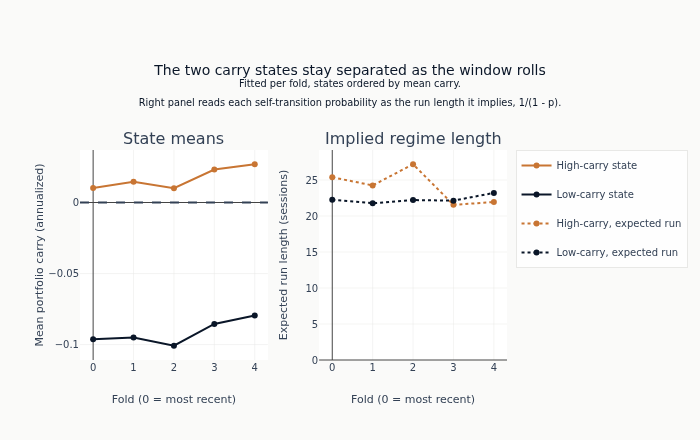

In [26]:
if len(hmm_param_df) > 0:
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=["State means", "Implied regime length"],
        horizontal_spacing=0.12,
    )
    for column, name, color in (
        ("mean_carry_high", "High-carry state", COLORS["copper"]),
        ("mean_carry_low", "Low-carry state", COLORS["blue"]),
    ):
        fig.add_trace(
            go.Scatter(
                x=hmm_param_df["fold"].to_list(),
                y=hmm_param_df[column].to_list(),
                mode="lines+markers",
                name=name,
                line={"color": color},
                legendgroup=name,
            ),
            row=1,
            col=1,
        )
    for column, name, color in (
        ("persist_high", "High-carry, expected run", COLORS["copper"]),
        ("persist_low", "Low-carry, expected run", COLORS["blue"]),
    ):
        fig.add_trace(
            go.Scatter(
                x=hmm_param_df["fold"].to_list(),
                y=(1.0 / (1.0 - hmm_param_df[column])).to_list(),
                mode="lines+markers",
                name=name,
                line={"color": color, "dash": "dot"},
                legendgroup=name,
            ),
            row=1,
            col=2,
        )
    fig.add_hline(y=0.0, line_dash="dash", line_color=COLORS["neutral"], row=1, col=1)
    fig.update_yaxes(title_text="Mean portfolio carry (annualized)", row=1, col=1)
    fig.update_yaxes(title_text="Expected run length (sessions)", rangemode="tozero", row=1, col=2)
    fig.update_xaxes(title_text="Fold (0 = most recent)", row=1, col=1)
    fig.update_xaxes(title_text="Fold (0 = most recent)", row=1, col=2)
    fig.update_layout(
        title=(
            "The two carry states stay separated as the window rolls"
            "<br><sup>Fitted per fold, states ordered by mean carry."
            "<br>Right panel reads each self-transition probability as the run length it "
            "implies, 1/(1 - p).</sup>"
        ),
        height=440,
        margin={"t": 150},
    )
    fig.show()

---

## 6. Assemble Temporal Features

Merge ARIMA, FFT, and HMM features into a single temporal feature matrix.
The output schema is `(fold, timestamp, product, position)` to align with Ch8
features and enable per-fold join downstream.

In [27]:
# Start with the full product-date-position grid, replicated per fold
base_grid = df.select(["timestamp", "product", "position"]).unique()
base = pl.concat([base_grid.with_columns(pl.lit(s["fold"]).alias("fold")) for s in splits])

# Join ARIMA (product-date-fold level)
if len(arima_pl) > 0:
    base = base.join(arima_pl, on=["product", "timestamp", "fold"], how="left")
    print(
        f"ARIMA features joined: {[c for c in arima_pl.columns if c not in ('product', 'timestamp', 'fold')]}"
    )
else:
    base = base.with_columns(
        pl.lit(None).cast(pl.Float64).alias("arima_carry_forecast"),
        pl.lit(None).cast(pl.Float64).alias("arima_carry_residual"),
    )

ARIMA features joined: ['arima_carry_forecast', 'arima_carry_residual']


In [28]:
# Join FFT (product-date-fold level)
if len(fft_pl) > 0:
    base = base.join(fft_pl, on=["product", "timestamp", "fold"], how="left")
    print(
        f"FFT features joined: {[c for c in fft_pl.columns if c not in ('product', 'timestamp', 'fold')]}"
    )
else:
    for col in [
        "fft_spectral_energy",
        "fft_dominant_period",
        "fft_spectral_entropy",
        "fft_energy_63d",
        "fft_energy_126d",
    ]:
        base = base.with_columns(pl.lit(None).cast(pl.Float64).alias(col))

FFT features joined: ['fft_spectral_energy', 'fft_dominant_period', 'fft_spectral_entropy', 'fft_energy_63d', 'fft_energy_126d']


In [29]:
# Join HMM (date-fold level, same regime for all products within a fold)
if len(hmm_pl) > 0:
    base = base.join(hmm_pl, on=["timestamp", "fold"], how="left")
    print(f"HMM features joined: {[c for c in hmm_pl.columns if c not in ('timestamp', 'fold')]}")
else:
    base = base.with_columns(
        pl.lit(None).cast(pl.Float64).alias("hmm_carry_regime_prob"),
        pl.lit(None).cast(pl.Float64).alias("hmm_regime_duration"),
    )

temporal_features = base.sort(["fold", "product", "position", "timestamp"])

HMM features joined: ['hmm_carry_regime_prob', 'hmm_regime_duration']


In [30]:
# Summary (exclude fold from feature columns)
temporal_cols = [
    c for c in temporal_features.columns if c not in ("timestamp", "product", "position", "fold")
]
print(
    f"\nTemporal feature matrix: {len(temporal_features):,} rows, {len(temporal_cols)} features, "
    f"{temporal_features['fold'].n_unique()} folds"
)
print(f"Features: {temporal_cols}")


Temporal feature matrix: 1,564,295 rows, 9 features, 5 folds
Features: ['arima_carry_forecast', 'arima_carry_residual', 'fft_spectral_energy', 'fft_dominant_period', 'fft_spectral_entropy', 'fft_energy_63d', 'fft_energy_126d', 'hmm_carry_regime_prob', 'hmm_regime_duration']


In [31]:
# Coverage (non-null percentage per feature)
print("\nFeature coverage (% non-null):")
for col in temporal_cols:
    non_null = temporal_features.select(pl.col(col).is_not_null().sum()).item()
    pct = non_null / len(temporal_features) * 100
    print(f"  {col}: {pct:.1f}%")


Feature coverage (% non-null):
  arima_carry_forecast: 20.4%
  arima_carry_residual: 20.4%
  fft_spectral_energy: 97.1%
  fft_dominant_period: 97.1%
  fft_spectral_entropy: 97.1%
  fft_energy_63d: 97.1%
  fft_energy_126d: 97.1%
  hmm_carry_regime_prob: 59.0%
  hmm_regime_duration: 59.0%


**Coverage note**: With per-fold fitting, ARIMA and HMM features cover both the
later training dates and the test window within each fold. Every ARIMA value is
an out-of-sample 1-step-ahead walk-forward forecast: the value at date `t` uses only
data before `t`.

ARIMA's coverage is far below the other two families in the table below, and two
things hold it there: the burn-in head, which is NaN by construction, and the uniform
walk length taken from the shortest eligible series in each fold. Both losses fall on
the early part of a fold's window, which is training. **The table below is over the
whole panel and understates what the downstream join gets**: the count printed under
the ARIMA seal is the one that matters, taken against the product-sessions each
validation window actually quotes, and it is complete or nearly so. FFT features are
deterministic over a backward-looking window and identical across folds; the HMM
covers each fold's train-plus-validation span, one value per session shared by every
product.

### Downstream Merge Note

`features/financial.parquet` (Ch8) and `features/model_based.parquet`
(this notebook) are **independent artifacts**. The downstream consumer
(Ch11+) joins them on `(fold, timestamp, product, position)`. The `fold`
column ensures each fold's training and test data get the temporal features
fitted on that fold's training data only, so there is no look-ahead bias.

## 7. Save Temporal Features

Before writing, three things are checked against the frame rather than asserted
about it: the panel key is unique, no fold's rows escape its own window, and the
columns that are populated inside the sealed region are exactly the ones that are
allowed to be.

That last check is the one worth reading. ARIMA and the HMM both estimate
parameters, and both are confined to their fold, so every sealed-date cell they
own must be null. FFT estimates nothing - it is a rolling transform over past
observations - so its sealed-date cells are populated on purpose, and a downstream
holdout evaluation needs them. A count is printed per column so the distinction is
visible rather than argued.

In [32]:
key = ["fold", "timestamp", "product", "position"]
duplicate_keys = temporal_features.select(pl.struct(key).is_duplicated().sum()).item()
assert duplicate_keys == 0, f"{duplicate_keys} duplicate rows on {key}"

FITTED_COLUMNS = [
    "arima_carry_forecast",
    "arima_carry_residual",
    "hmm_carry_regime_prob",
    "hmm_regime_duration",
]
FFT_COLUMNS = [c for c in temporal_cols if c.startswith("fft_")]
assert sorted(FITTED_COLUMNS + FFT_COLUMNS) == sorted(temporal_cols), (
    "a feature column belongs to neither the fitted nor the FFT family; "
    "classify it before the seal check can mean anything"
)

sealed = temporal_features.filter(pl.col("timestamp") >= HOLDOUT_START)
print(f"Panel key {key} unique across {len(temporal_features):,} rows")
print(f"Rows dated inside the seal: {len(sealed):,} of {len(temporal_features):,}")
print("Non-null cells on those rows, by column:")
for col in temporal_cols:
    n_sealed = sealed.select(pl.col(col).is_not_null().sum()).item()
    family = "fitted" if col in FITTED_COLUMNS else "FFT"
    print(f"  {col:<26s} {family:<7s} {n_sealed:>8,}")
for col in FITTED_COLUMNS:
    n_sealed = sealed.select(pl.col(col).is_not_null().sum()).item()
    assert n_sealed == 0, f"{col} is a fitted feature with {n_sealed} values inside the seal"

Panel key ['fold', 'timestamp', 'product', 'position'] unique across 1,564,295 rows
Rows dated inside the seal: 217,605 of 1,564,295
Non-null cells on those rows, by column:
  arima_carry_forecast       fitted         0
  arima_carry_residual       fitted         0
  fft_spectral_energy        FFT      216,330
  fft_dominant_period        FFT      216,330
  fft_spectral_entropy       FFT      216,330
  fft_energy_63d             FFT      216,330
  fft_energy_126d            FFT      216,330
  hmm_carry_regime_prob      fitted         0
  hmm_regime_duration        fitted         0


In [33]:
output_path = FEATURES_DIR / "model_based.parquet"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
temporal_features.write_parquet(output_path)
# Report the canonical repo-relative destination (stable regardless of an
# ML4T_OUTPUT_DIR test/isolation redirect).
print(f"Saved temporal features to case_studies/{STRATEGY_ID}/features/model_based.parquet")

Saved temporal features to case_studies/cme_futures/features/model_based.parquet


## 8. Incremental Evaluation

Do temporal features add predictive value beyond the stage-03 features?
Per-feature rank IC is computed against the case study's primary label -
`PRIMARY_LABEL`, read from `setup.yaml` above - with HAC-adjusted standard
errors. This screen selects nothing; `05_evaluation` does that.

Two scoping rules make the number mean what its name says. **Validation rows
only**: each fold contributes the rows dated inside its own validation window,
and nothing from its training window, which is what makes the estimate
out-of-sample. **The outcome endpoint, not the decision
date, bounds the seal**: a decision on date `t` carrying a forward return over
`LABEL_HORIZON_SESSIONS` sessions is realized that many sessions later, so the
last usable decision date is the one whose label resolves before the holdout
opens. Both boundaries are printed in section 1.

In [34]:
temporal_ic = {}

Helper: build the evaluation panel for temporal-feature IC testing.

In [35]:
def _build_temporal_eval_frame(features_df: pl.DataFrame):
    label_path = CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet"
    if not label_path.exists():
        return None, None
    label_df = pl.read_parquet(label_path)
    label_col = [c for c in label_df.columns if c not in ("timestamp", "product", "position")][0]

    # Validation rows only, taken per fold from that fold's own validation window.
    validation = pl.concat(
        [
            features_df.filter(
                (pl.col("fold") == split["fold"])
                & (pl.col("timestamp") >= _as_date(split["val_start"]))
                & (pl.col("timestamp") <= _as_date(split["val_end"]))
            )
            for split in splits
        ]
    )

    eval_df = (
        validation.filter(pl.col("position") == 0)
        .join(
            label_df.filter(pl.col("position") == 0).select(["timestamp", "product", label_col]),
            on=["timestamp", "product"],
            how="inner",
        )
        .filter(pl.col("timestamp") <= LAST_SEALED_DECISION_DATE)
        .unique(subset=["timestamp", "product"], keep="first")
        .sort(["timestamp", "product"])
    )
    return eval_df, label_col

Helper: compute HAC-adjusted IC statistics for each temporal feature.

The per-date IC series comes from `cross_sectional_ic_series`, which returns its rows
in date order. That is the property the next call depends on: `compute_ic_hac_stats`
reads row order as time order and does not sort, so a series assembled by grouping
would hand Newey-West an arbitrary permutation of the timeline and return a standard
error for a lag structure the data does not have. The lag itself is
`LABEL_HORIZON_SESSIONS`, because consecutive daily decisions share all but one day
of their outcome window.

In [36]:
def _compute_temporal_ic_stats(eval_df, feature_cols, label_col):
    from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

    output = {}
    labels = eval_df.select(["timestamp", "product", label_col])
    for feat in feature_cols:
        ic_series = cross_sectional_ic_series(
            eval_df.select(["timestamp", "product", feat]),
            labels,
            pred_col=feat,
            ret_col=label_col,
            date_col="timestamp",
            entity_col="product",
            method="spearman",
            min_obs=10,
        )
        ic_vals = ic_series["ic"].drop_nulls().drop_nans().to_numpy()
        if len(ic_vals) >= 20:
            output[feat] = compute_ic_hac_stats(ic_vals, label_horizon=LABEL_HORIZON_SESSIONS)
            # How many decision dates the estimate rests on. A feature whose panel is
            # thin on some dates loses them to `min_obs`, and the HAC lag is stated in
            # sessions, so the count belongs beside the t-statistic.
            output[feat]["n_dates"] = len(ic_vals)
    return output

Helper: apply FDR correction to the per-feature HAC significance tests.

In [37]:
def _apply_fdr_significance(ic_stats: dict[str, dict]) -> list[bool]:
    from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr

    features = list(ic_stats.keys())
    p_values = [ic_stats[f]["p_value"] for f in features]
    fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)
    rejected = fdr_result["rejected"].tolist()
    for idx, feat in enumerate(features):
        ic_stats[feat]["fdr_significant"] = rejected[idx]
    return rejected

In [38]:
if len(temporal_features) > 0:
    eval_df, label_col = _build_temporal_eval_frame(temporal_features)
    if eval_df is None:
        print("Label file not found, skipping incremental evaluation")
    else:
        print(
            f"Incremental eval set: {len(eval_df):,} rows "
            f"(front-month, pre-holdout), label: {label_col}"
        )
        temporal_ic = _compute_temporal_ic_stats(eval_df, temporal_cols, label_col)
        if temporal_ic:
            rejected = _apply_fdr_significance(temporal_ic)
            n_fdr_sig = sum(rejected)
            n_naive_sig = sum(1 for f in temporal_ic if abs(temporal_ic[f]["t_stat"]) > 1.96)
            print(f"\nTemporal features tested: {len(temporal_ic)} of {len(temporal_cols)}")
            print(f"Naive significant (|t|>1.96): {n_naive_sig}")
            print(f"FDR significant (alpha=0.05): {n_fdr_sig}")
            for feat in sorted(temporal_ic, key=lambda x: -abs(temporal_ic[x]["mean_ic"])):
                sig = "**" if temporal_ic[feat]["fdr_significant"] else " "
                print(
                    f"  {sig} {feat:<30s} IC={temporal_ic[feat]['mean_ic']:+.5f}  "
                    f"HAC t={temporal_ic[feat]['t_stat']:+.2f}  "
                    f"dates={temporal_ic[feat]['n_dates']:,}"
                )
else:
    print("[TEST] Skipping incremental evaluation")

Incremental eval set: 38,244 rows (front-month, pre-holdout), label: fwd_ret_5d



Temporal features tested: 7 of 9
Naive significant (|t|>1.96): 1
FDR significant (alpha=0.05): 0
    fft_energy_63d                 IC=-0.03116  HAC t=-2.10  dates=1,285
    fft_dominant_period            IC=+0.01607  HAC t=+1.47  dates=1,285
    arima_carry_forecast           IC=-0.01463  HAC t=-1.37  dates=1,284
    fft_spectral_entropy           IC=+0.01408  HAC t=+1.15  dates=1,285
    arima_carry_residual           IC=-0.01126  HAC t=-1.67  dates=1,284
    fft_energy_126d                IC=-0.00341  HAC t=-0.27  dates=1,285
    fft_spectral_energy            IC=+0.00328  HAC t=+0.21  dates=1,285


### What the Screen Found

Signed mean IC per feature, sorted, with the bars that clear the Benjamini-Hochberg
screen filled and the rest drawn hollow. Read the FDR distinction rather than the
naive one: every temporal feature was screened against the same label on the same
validation rows, so that is a family, and a large per-feature t-statistic inside it
is not a discovery on its own. The alpha, the counts and the t-statistics are
printed above.

The two HMM features are absent from the chart because they are constant across
products within a decision date, so a cross-sectional rank correlation on them is
undefined. Nothing here says they are worthless: a regime variable acts by
conditioning other signals, and testing that needs an interaction or a
with-and-without model comparison. This stage runs neither, and neither does the
univariate screen in `05_evaluation`.

**This selects nothing.** Every feature above is already written to
`model_based.parquet` in section 7, whatever the bar says.

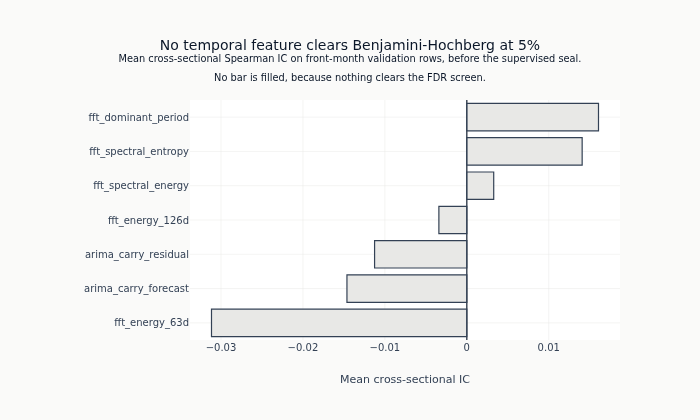

In [39]:
if temporal_ic:
    ic_rows = sorted(temporal_ic.items(), key=lambda item: item[1]["mean_ic"])
    names = [name for name, _ in ic_rows]
    values = [stats["mean_ic"] for _, stats in ic_rows]
    retained = [bool(stats["fdr_significant"]) for _, stats in ic_rows]
    # Filled where retained, hollow where not: the palette's dark end is four navies
    # that do not separate as bars, so the distinction is carried by lightness.
    fill = [
        (COLORS["blue"] if value >= 0 else COLORS["copper"]) if keep else COLORS["silver_muted"]
        for value, keep in zip(values, retained, strict=True)
    ]
    edge = [
        (COLORS["blue"] if value >= 0 else COLORS["copper"]) if keep else COLORS["neutral"]
        for value, keep in zip(values, retained, strict=True)
    ]
    fig = go.Figure(
        go.Bar(
            x=values,
            y=names,
            orientation="h",
            marker={"color": fill, "line": {"color": edge, "width": 1.2}},
            showlegend=False,
        )
    )
    fig.add_vline(x=0, line_color=COLORS["neutral"], line_width=1)
    fig.update_layout(
        title=(
            "No temporal feature clears Benjamini-Hochberg at 5%"
            if n_fdr_sig == 0
            else "Temporal feature IC on the validation folds"
        )
        + (
            "<br><sup>Mean cross-sectional Spearman IC on front-month validation rows, "
            "before the supervised seal.<br>"
            + (
                "No bar is filled, because nothing clears the FDR screen.</sup>"
                if n_fdr_sig == 0
                else "Filled bars clear the FDR screen; hollow bars do not.</sup>"
            )
        ),
        xaxis_title="Mean cross-sectional IC",
        yaxis_title="",
        height=420,
        margin={"l": 190},
    )
    fig.show()
else:
    print("Validation IC chart omitted: no feature produced enough per-date observations.")

## 9. What the HMM Inferred, on Validation Sessions

The regime feature is only useful downstream if the state it decodes holds long
enough to condition anything. So the cell below measures the run lengths per fold
rather than describing them: the shortest run, the median run, the longest, and the
share of validation sessions that sit inside a run of a month or more.

The shortest and the longest are both reported because the mean is not a summary of
this distribution. A fold whose sessions are almost all inside two or three long
blocks still contains a handful of one- and two-session flips, and averaging over the
blocks hides them.

The figure after it draws one fold's validation window: the observation the model
reads on top, the state it filters out of that observation below. A fold's full
train-plus-validation span is an order of magnitude longer, and runs of the lengths
printed below render as a picket fence at that density.

In [40]:
if len(hmm_pl) > 0:
    HELD_RUN_SESSIONS = 21  # one trading month

    def _run_lengths(states: np.ndarray) -> list[int]:
        if len(states) == 0:
            return []
        edges = np.flatnonzero(np.diff(states) != 0) + 1
        return np.diff([0, *edges.tolist(), len(states)]).tolist()

    run_rows = []
    for sp in splits:
        window = (
            hmm_pl.filter(pl.col("fold") == sp["fold"])
            .filter(
                (pl.col("timestamp") >= _as_date(sp["val_start"]))
                & (pl.col("timestamp") <= _as_date(sp["val_end"]))
            )
            .sort("timestamp")
        )
        states = (window["hmm_carry_regime_prob"] > 0.5).cast(int).to_numpy()
        runs = _run_lengths(states)
        held = sum(r for r in runs if r >= HELD_RUN_SESSIONS)
        run_rows.append(
            {
                "fold": sp["fold"],
                "val_sessions": len(states),
                "state_changes": max(len(runs) - 1, 0),
                "shortest_run": min(runs) if runs else 0,
                "median_run": float(np.median(runs)) if runs else 0.0,
                "longest_run": max(runs) if runs else 0,
                "pct_sessions_in_month_plus_runs": 100 * held / max(len(states), 1),
            }
        )
    print("\nDecoded-state run lengths on validation sessions, per fold:")
    print(pl.DataFrame(run_rows))


Decoded-state run lengths on validation sessions, per fold:
shape: (5, 7)
┌──────┬──────────────┬───────────────┬──────────────┬────────────┬─────────────┬──────────────────┐
│ fold ┆ val_sessions ┆ state_changes ┆ shortest_run ┆ median_run ┆ longest_run ┆ pct_sessions_in_ │
│ ---  ┆ ---          ┆ ---           ┆ ---          ┆ ---        ┆ ---         ┆ month_plus_run…  │
│ i64  ┆ i64          ┆ i64           ┆ i64          ┆ f64        ┆ i64         ┆ ---              │
│      ┆              ┆               ┆              ┆            ┆             ┆ f64              │
╞══════╪══════════════╪═══════════════╪══════════════╪════════════╪═════════════╪══════════════════╡
│ 0    ┆ 253          ┆ 13            ┆ 1            ┆ 8.5        ┆ 77          ┆ 74.703557        │
│ 1    ┆ 258          ┆ 16            ┆ 1            ┆ 11.0       ┆ 58          ┆ 55.426357        │
│ 2    ┆ 258          ┆ 12            ┆ 1            ┆ 5.0        ┆ 121         ┆ 86.434109        │
│ 3    ┆ 258    

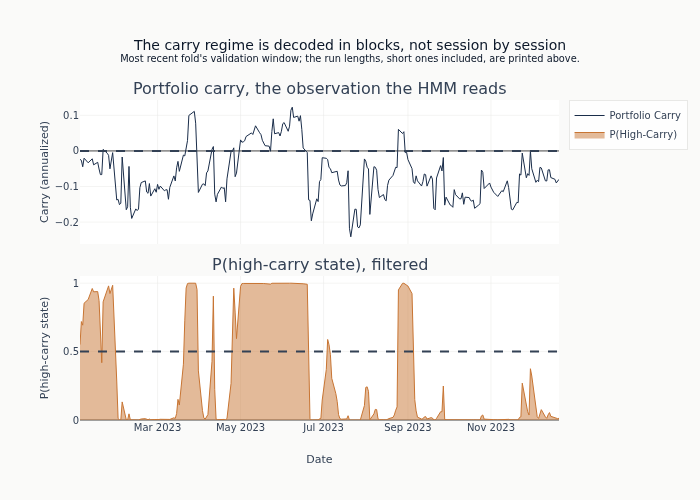

In [41]:
if len(hmm_pl) > 0:
    viz_fold = hmm_pl["fold"].min()
    viz_split = next(sp for sp in splits if sp["fold"] == viz_fold)
    hmm_viz = (
        hmm_pl.filter(pl.col("fold") == viz_fold)
        .filter(
            (pl.col("timestamp") >= _as_date(viz_split["val_start"]))
            & (pl.col("timestamp") <= _as_date(viz_split["val_end"]))
        )
        .sort("timestamp")
    )
    port_viz = portfolio_carry.join(
        hmm_viz.select(["timestamp", "hmm_carry_regime_prob"]), on="timestamp", how="inner"
    ).sort("timestamp")

    fig = make_subplots(
        rows=2,
        cols=1,
        shared_xaxes=True,
        subplot_titles=[
            "Portfolio carry, the observation the HMM reads",
            "P(high-carry state), filtered",
        ],
        vertical_spacing=0.1,
    )

    fig.add_trace(
        go.Scatter(
            x=port_viz["timestamp"].to_list(),
            y=port_viz["portfolio_carry"].to_list(),
            name="Portfolio Carry",
            line=dict(width=1, color=COLORS["slate"]),
        ),
        row=1,
        col=1,
    )
    fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=1, col=1)

    fig.add_trace(
        go.Scatter(
            x=port_viz["timestamp"].to_list(),
            y=port_viz["hmm_carry_regime_prob"].to_list(),
            name="P(High-Carry)",
            line=dict(width=1, color=COLORS["copper"]),
            fill="tozeroy",
        ),
        row=2,
        col=1,
    )
    fig.add_hline(y=0.5, line_dash="dash", line_color=COLORS["neutral"], row=2, col=1)

    fig.update_layout(
        height=500,
        title_text=(
            "The carry regime is decoded in blocks, not session by session"
            "<br><sup>Most recent fold's validation window; the run lengths, short ones "
            "included, are printed above.</sup>"
        ),
    )
    fig.update_yaxes(title_text="Carry (annualized)", row=1, col=1)
    fig.update_yaxes(title_text="P(high-carry state)", row=2, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.show()

In [42]:
print("\n" + "=" * 60)
print("TEMPORAL FEATURES SUMMARY")
print("=" * 60)
print(f"Total features: {len(temporal_cols)}")
print("  ARIMA: arima_carry_forecast, arima_carry_residual")
print(
    "  FFT: fft_spectral_energy, fft_dominant_period, fft_spectral_entropy, "
    "fft_energy_63d, fft_energy_126d"
)
print("  HMM: hmm_carry_regime_prob, hmm_regime_duration")
print(f"Rows: {len(temporal_features):,}")
print(f"Products: {temporal_features['product'].n_unique()}")
print(f"Folds: {temporal_features['fold'].n_unique()}")
print("=" * 60)


TEMPORAL FEATURES SUMMARY
Total features: 9
  ARIMA: arima_carry_forecast, arima_carry_residual
  FFT: fft_spectral_energy, fft_dominant_period, fft_spectral_entropy, fft_energy_63d, fft_energy_126d
  HMM: hmm_carry_regime_prob, hmm_regime_duration
Rows: 1,564,295
Products: 30
Folds: 5


## Key Takeaways

1. **ARIMA on carry z-score** captures the predictable mean-reverting
   component of term structure dynamics. Every value is an out-of-sample
   1-step-ahead walk-forward forecast (predicted from data strictly before
   each date), covering the later training dates and the test window alike.
2. **FFT spectral features** read the carry spectrum inside a trailing window.
   The dominant period is whatever that spectrum peaks at rather than a cycle
   assumed in advance; the two energy bands are a declared choice,
   `FFT_TARGET_PERIODS`, quarterly and semi-annual. As a deterministic rolling
   transform, FFT is identical across folds.
3. **HMM regime detection** decodes a two-state carry regime from one
   portfolio-level observation per session. The basket behind that observation is
   only partly stable: a product that misses a settlement keeps its last one for
   two sessions, which covers four fifths of the absences, and a longer absence
   still drops it. Section 5 prints both the run lengths and the resulting basket
   sizes. Filtered (not smoothed) probabilities prevent look-ahead bias.
4. All temporal models are fitted **per fold**: parameters estimated on
   training data only, features extracted for both train+test periods.
   The `fold` column enables downstream per-fold join.

**Artifacts**: `features/model_based.parquet` (with `fold` column)

**Next**: Chapter 11+ for ML models combining Ch8 cross-sectional features
with Ch9 temporal features.